In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')

from thresholding.helpers import ObserveAttentionHelper
from hira.indexer import CPUIndexer
from hira.searcher import CPUSearcher

import matplotlib.pyplot as plt
import torch
import numpy as np
import time
import random
from tqdm import tqdm
import pandas as pd;

/home/mohsen/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mohsen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load real data

In [ ]:
model_name = "meta-llama/Llama-3.2-3B-Instruct"
max_new_tokens = 100000
prompt = """
Write a detailed essay on the history of artificial intelligence, covering key milestones, influential researchers, and major breakthroughs in the field. Discuss the evolution of AI from its inception to the present day, including the development of machine learning, deep learning, and neural networks. Highlight the impact of AI on various industries and society as a whole, as well as ethical considerations and future prospects for AI technology.
"""

In [ ]:
observer = ObserveAttentionHelper(model_name, max_new_tokens=max_new_tokens)
observer.run_model(prompt)

In [ ]:
attn_info = observer.get_attention_info()
attn_info

### Benchmarking

In [ ]:
# config
config = {
    # indexer
    "num_levels": [5],
    "branching_factor": [8],
    "balance_every": [2**9],
    # general
    "update_every": [2**9],
    "output_csv": "result_v1.0.csv",
    # searcher
    "chunk_size": [8 * 1024],
    "methods": [
        "search_numba_vectorized",
        "search_torch_vectorized",
        "search_cpp_vectorized",
        "search_numba_loop",
        "search_torch_loop",
        "search_cpp_loop",
        "search_fused",
        "search_fused_torch_ext",
        "search_exact_torch_ext",
        "brute_force",
    ],
}

In [ ]:
observer.snapshot()

In [ ]:
def repeat_kv(x, n_rep):
    # x: [batch, n_kv_heads, seq_len, head_dim]
    b, n_kv, s, d = x.shape

    x = x[:, :, None, :, :]  # [b, n_kv, 1, s, d]
    x = x.expand(b, n_kv, n_rep, s, d)  # [b, n_kv, n_rep, s, d]
    return x.reshape(b, n_kv * n_rep, s, d)  # [b, n_kv*n_rep, s, d]


def run_benchmark(
    layer_idx, observer, num_levels, branching_factor, balance_every, update_every
):
    print("Loading key/queries...")
    keys = observer.get_keys_tensor()[layer_idx, :].unsqueeze(0).to("cpu").contiguous()
    keys = repeat_kv(keys, attn_info["num_q_heads"] // attn_info["num_kv_heads"])
    queries = (
        observer.get_queries_tensor()[layer_idx, :].unsqueeze(0).to("cpu").contiguous()
    )
    print(f"query shape: {queries.shape}, key shape: {keys.shape}")

    print("\tBuilding index...")
    indexer = CPUIndexer(
        num_levels=num_levels,
        branching_factor=branching_factor,
        max_iterations=1,
        balance_every=balance_every,
    ).build(
        keys[:, :, : attn_info["prompt_length"], :]
    )  # only first prefilled keys

    result = {
        "position": [],
        "method": [],
        "time": [],
        "chunk_size": [],
        "update_time": [],
        "num_levels": [],
        "branching_factor": [],
        "balance_every": [],
        "update_every": [],
    }

    for i in tqdm(range(0, queries.size(2), update_every), desc="Querying"):
        query = queries[:, :, i : i + 1, :]

        update_time = 0
        if i % update_every == 0:
            update_start = time.time()
            indexer.update(keys[:, :, i - update_every : i, :])
            update_end = time.time()
            update_time = update_end - update_start

        # threshold
        scores = (query * keys).sum(dim=-1)
        # n-th largest = kth smallest of negative (shape = H)
        threshold = (-scores).kthvalue(k=20, dim=-1).values
        threshold = -threshold.squeeze(0)

        for chunk_size in config["chunk_size"]:
            for method in config["methods"]:
                vectorize = "vectorized" in method
                kernel = (
                    "numba"
                    if "numba" in method
                    else "cpp" if "cpp" in method else "torch"
                )
                searcher = CPUSearcher(
                    chunk_size=chunk_size, vectorize=vectorize, kernel=kernel
                )

                if method == "search_fused":
                    start = time.time()
                    searcher.search_fused(query, threshold, indexer)
                    end = time.time()
                elif method == "search_fused_torch_ext":
                    start = time.time()
                    searcher.search_fused_torch_ext(query, threshold, indexer)
                    end = time.time()
                elif method == "search_exact_torch_ext":
                    start = time.time()
                    searcher.search_exact_torch_ext(query, threshold, indexer)
                    end = time.time()
                elif method == "brute_force":
                    start = time.time()
                    query = query / query.norm(dim=-1, keepdim=True)
                    scores = torch.matmul(query, keys[:, :, :i, :].transpose(-2, -1))
                    end = time.time()
                else:  # search
                    start = time.time()
                    searcher.search(query, threshold, indexer)
                    end = time.time()

                result["method"].append(method)
                result["chunk_size"].append(chunk_size)
                result["time"].append(end - start)
                result["position"].append(i)
                result["update_time"].append(update_time)
                result["num_levels"].append(num_levels)
                result["branching_factor"].append(branching_factor)
                result["balance_every"].append(balance_every)
                result["update_every"].append(update_every)

        if i % 100 == 0:
            pd.DataFrame(result).to_csv(config["output_csv"], index=False)

    return pd.DataFrame(result)

In [ ]:
layer_idx = 20

df = None

for num_levels in config["num_levels"]:
    for branching_factor in config["branching_factor"]:
        for update_every in config["update_every"]:
            for balance_every in config["balance_every"]:
                print(
                    f"levels={num_levels} | bf={branching_factor} | update={update_every} | balance={balance_every}"
                )
                result = run_benchmark(
                    layer_idx,
                    observer,
                    num_levels,
                    branching_factor,
                    balance_every,
                    update_every,
                )
                if df is not None:
                    df = pd.concat([df, result])
                else:
                    df = result

                df.to_csv(config["output_csv"], index=False)

### Analyze

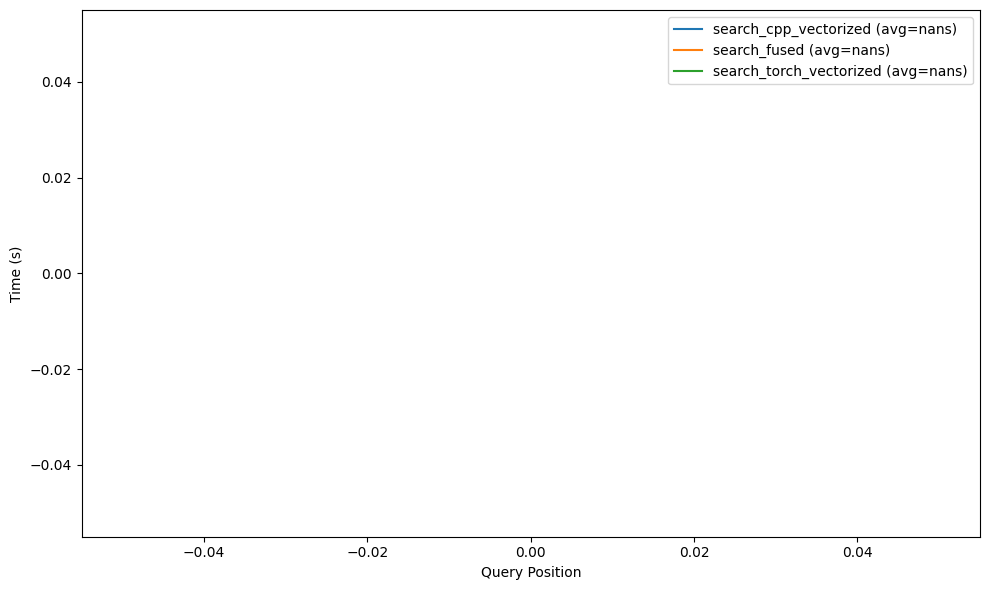

In [4]:
result = pd.read_csv(config["output_csv"])

pivot = result.pivot(index="position", columns="method", values="time")
pivot = pivot.rolling(100).mean()

plt.figure(figsize=(10, 6))

for method in pivot.columns:
    avg_time = pivot[method].mean()
    plt.plot(pivot.index, pivot[method], label=f"{method} (avg={avg_time:.6f}s)")

plt.xlabel("Query Position")
plt.ylabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()